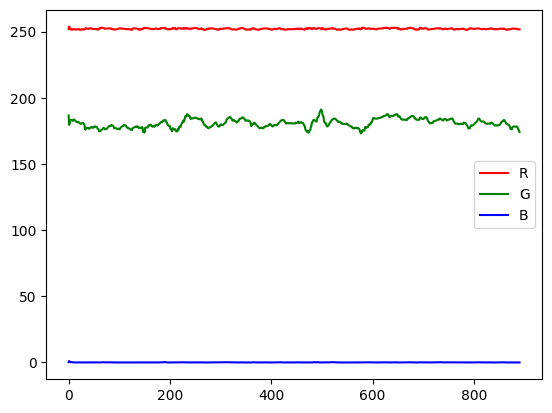

In [13]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("output.txt")

R = data[:,0]
G = data[:,1]
B = data[:,2]

plt.plot(R, label="R", color="red")
plt.plot(G, label="G", color="green")
plt.plot(B, label="B", color="blue")
plt.legend()
plt.show()


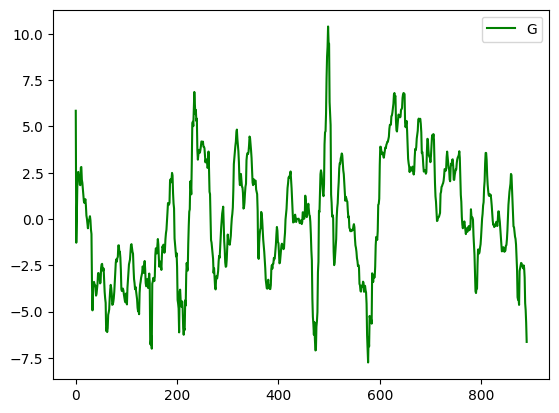

In [10]:
data = np.loadtxt("output.txt")

G = data[:,1]
G_ac = G - np.mean(G)

plt.plot(G_ac, label="G", color="green")
plt.legend()
plt.show()

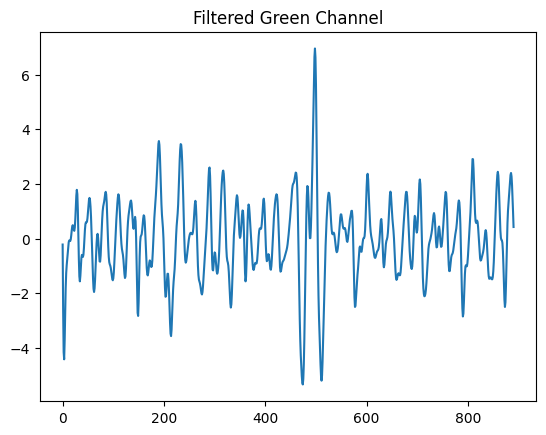

In [11]:
from scipy.signal import butter, filtfilt

fs = 30

lowcut = 0.5
highcut = 4

b, a = butter(3, [lowcut/(fs/2), highcut/(fs/2)], btype='band')

G_filt = filtfilt(b, a, G_ac)

plt.plot(G_filt)
plt.title("Filtered Green Channel")
plt.show()



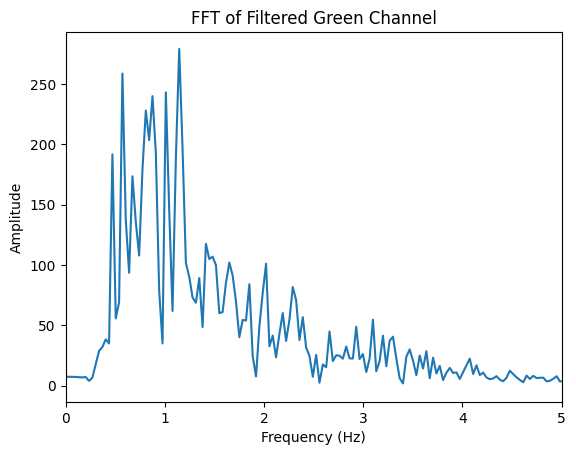

Peak frequency: 1.145 Hz
Estimated heart rate: 68.7 bpm


In [16]:
N = len(G_filt)
freqs = np.fft.rfftfreq(N, 1/fs)
fft_vals = np.abs(np.fft.rfft(G_filt))

plt.figure()
plt.plot(freqs, fft_vals)
plt.xlim(0,5)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT of Filtered Green Channel")
plt.show()




mask = (freqs >= 0.5) & (freqs <= 4)
freqs_band = freqs[mask]
fft_band = fft_vals[mask]

peak_freq = freqs_band[np.argmax(fft_band)]
bpm = peak_freq * 60

print(f"Peak frequency: {peak_freq:.3f} Hz")
print(f"Estimated heart rate: {bpm:.1f} bpm")

